In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv(r'../data/data.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [4]:
df.loc[df['TotalCharges']==' ','TotalCharges']=np.nan

In [5]:
binary_list=[]
for i in df.columns:
    if (df[i][0]=='Yes')|(df[i][0]=='No'):
        binary_list.append(i)

In [6]:
for i in binary_list:
    df[i]=np.where(df[i]=='Yes',1,0)
    

In [7]:
df.gender=np.where(df.gender=='Male',1,0)

In [8]:
df.MultipleLines=np.where(df.MultipleLines=='Yes',1,0)

In [9]:
df.head(5).T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,0,1,1,1,0
SeniorCitizen,0,0,0,0,0
Partner,1,0,0,0,0
Dependents,0,0,0,0,0
tenure,1,34,2,45,2
PhoneService,0,1,1,0,1
MultipleLines,0,0,0,0,0
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,0,1,1,1,0


In [10]:
df.InternetService.value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [11]:
df.Contract.value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [12]:
df=df.convert_dtypes()

In [13]:
df.TotalCharges=df.TotalCharges.astype('float64')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   string 
 1   gender            7043 non-null   Int64  
 2   SeniorCitizen     7043 non-null   Int64  
 3   Partner           7043 non-null   Int64  
 4   Dependents        7043 non-null   Int64  
 5   tenure            7043 non-null   Int64  
 6   PhoneService      7043 non-null   Int64  
 7   MultipleLines     7043 non-null   Int64  
 8   InternetService   7043 non-null   string 
 9   OnlineSecurity    7043 non-null   Int64  
 10  OnlineBackup      7043 non-null   Int64  
 11  DeviceProtection  7043 non-null   Int64  
 12  TechSupport       7043 non-null   Int64  
 13  StreamingTV       7043 non-null   Int64  
 14  StreamingMovies   7043 non-null   Int64  
 15  Contract          7043 non-null   string 
 16  PaperlessBilling  7043 non-null   Int64  


In [15]:
df.select_dtypes('number').describe(percentiles=[0.02,0.05,0.25,0.5,0.75,0.95,0.97]).T

,count,mean,std,min,2%,5%,25%,50%,75%,95%,97%,max
gender,7043.0,0.504756,0.500013,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0
SeniorCitizen,7043.0,0.162147,0.368612,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
Partner,7043.0,0.483033,0.499748,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
Dependents,7043.0,0.299588,0.45811,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
tenure,7043.0,32.371149,24.559481,0.0,1.0,1.0,9.0,29.0,55.0,72.0,72.0,72.0
PhoneService,7043.0,0.903166,0.295752,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
MultipleLines,7043.0,0.421837,0.493888,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
OnlineSecurity,7043.0,0.286668,0.452237,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
OnlineBackup,7043.0,0.344881,0.475363,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
DeviceProtection,7043.0,0.343888,0.475038,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0


In [16]:
df.describe(exclude='number')

,customerID,InternetService,Contract,PaymentMethod
count,7043,7043,7043,7043
unique,7043,3,3,4
top,7590-VHVEG,Fiber optic,Month-to-month,Electronic check
freq,1,3096,3875,2365


In [17]:
df.loc[df.PaymentMethod=='Electronic check','PaymentMethod']='Electronic'
df.loc[df.PaymentMethod=='Mailed check','PaymentMethod']='Mailed'
df.loc[df.PaymentMethod=='Bank transfer (automatic)','PaymentMethod']='Bank'
df.loc[df.PaymentMethod=='Credit card (automatic)','PaymentMethod']='Credit_card'

In [18]:
df.loc[df.Contract=='Month-to-month','Contract']='0'
df.loc[df.Contract=='One year','Contract']='1'
df.loc[df.Contract=='Two year','Contract']='2'
df.Contract=df.Contract.astype('int')

In [19]:
dummies_data=pd.get_dummies(df[['InternetService','PaymentMethod']],sparse=False,drop_first=True).apply(lambda x : x.astype('int'))

In [20]:
df.drop(columns=['InternetService','PaymentMethod'],inplace=True)

In [21]:
df1=pd.concat([df,dummies_data],axis=1)
df1.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit_card,PaymentMethod_Electronic,PaymentMethod_Mailed
0,7590-VHVEG,0,0,1,0,1,0,0,0,1,...,0,1,29.85,29.85,0,0,0,0,1,0
1,5575-GNVDE,1,0,0,0,34,1,0,1,0,...,1,0,56.95,1889.50,0,0,0,0,0,1
2,3668-QPYBK,1,0,0,0,2,1,0,1,1,...,0,1,53.85,108.15,1,0,0,0,0,1
3,7795-CFOCW,1,0,0,0,45,0,0,1,0,...,1,0,42.3,1840.75,0,0,0,0,0,0
4,9237-HQITU,0,0,0,0,2,1,0,0,0,...,0,1,70.7,151.65,1,1,0,0,1,0


### Feature Engineering

In [22]:
df['tenure_group']=df.tenure.apply(lambda x : 0 if x<12 else(1 if x>12 & x<=24 else (2 if x>24 & x<=36 else 3 )))

In [23]:
df1.drop(columns='customerID',inplace=True)

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

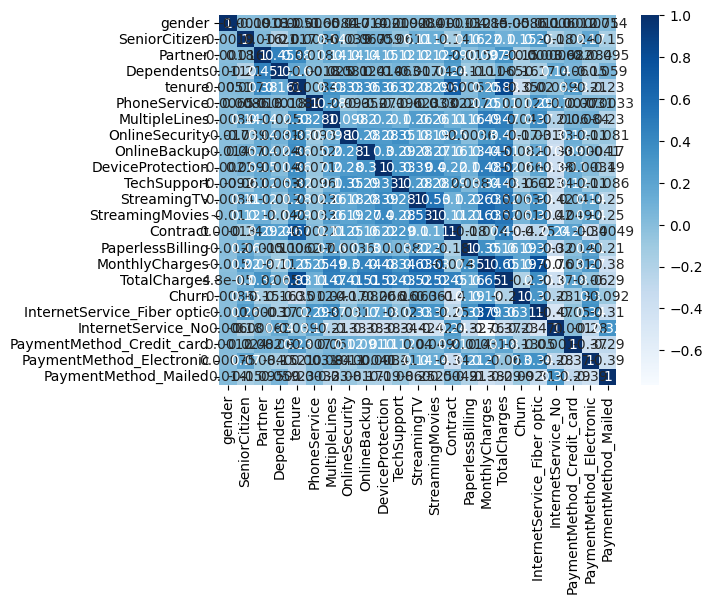

In [25]:
plt.Figure(figsize=[100,100])
sns.heatmap(df1.corr(),annot=True,cmap='Blues')
plt.show()

In [26]:
df1.corr()>0.7

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit_card,PaymentMethod_Electronic,PaymentMethod_Mailed
gender,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
SeniorCitizen,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
Partner,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
Dependents,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
tenure,False,False,False,False,True,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
PhoneService,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
MultipleLines,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
OnlineSecurity,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
OnlineBackup,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
DeviceProtection,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [27]:
df1.TotalCharges.fillna(df.TotalCharges.mean(),inplace=True)

C:\Users\PRASAD\AppData\Local\Temp\ipykernel_11616\28172457.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1.TotalCharges.fillna(df.TotalCharges.mean(),inplace=True)


In [28]:
df1.head(3).T

,0,1,2
gender,0,1,1
SeniorCitizen,0,0,0
Partner,1,0,0
Dependents,0,0,0
tenure,1,34,2
PhoneService,0,1,1
MultipleLines,0,0,0
OnlineSecurity,0,1,1
OnlineBackup,1,0,1
DeviceProtection,0,1,0


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [32]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'MonthlyCharges',
       'TotalCharges', 'Churn', 'tenure_group'],
      dtype='object')

In [33]:
x=df1.drop(columns='Churn')
y=df[['Churn']]

In [34]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=8)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


In [35]:
# Training Model

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, accuracy_score

def tune_and_evaluate_model(x_train, x_test, y_train, y_test, model, param_grid):
    """
    Performs Hyperparameter tuning and prints performance metrics for Churn prediction.
    """
    # 1. Hyperparameter Tuning
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, 
                               cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)
    grid_search.fit(x_train, y_train)
    
    best_model = grid_search.best_estimator_
    
    # 2. Predictions
    train_preds = best_model.predict(x_train)
    test_preds = best_model.predict(x_test)
    test_probs = best_model.predict_proba(x_test)[:, 1]
    
    # 3. Output Results
    print("-" * 30)
    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Best CV Score (AUC): {grid_search.best_score_:.4f}")
    print("-" * 30)
    
    print("\n[TRAIN DATA] Confusion Matrix:")
    print(confusion_matrix(y_train, train_preds))
    print(f"Train Accuracy: {accuracy_score(y_train, train_preds):.4f}")
    
    print("\n[TEST DATA] Confusion Matrix:")
    print(confusion_matrix(y_test, test_preds))
    print(f"\n[TEST DATA] Classification Report:")
    print(classification_report(y_test, test_preds))
    
    print(f"Final Test AUC Score: {roc_auc_score(y_test, test_probs):.4f}")
    print("-" * 30)
    
    return best_model

In [37]:
# Example for Random Forest
rf_grid = {
    'n_estimators': [50,100, 200],
    'max_depth': [5, 7, 10],
    'criterion': ['gini', 'entropy']
}

best_rf = tune_and_evaluate_model(x_train, x_test, y_train, y_test, RandomForestClassifier(), rf_grid)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


C:\Users\PRASAD\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


------------------------------
Best Parameters: {'criterion': 'entropy', 'max_depth': 7, 'n_estimators': 200}
Best CV Score (AUC): 0.8509
------------------------------

[TRAIN DATA] Confusion Matrix:
[[3815  324]
 [ 665  830]]
Train Accuracy: 0.8245

[TEST DATA] Confusion Matrix:
[[942  93]
 [186 188]]

[TEST DATA] Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.91      0.87      1035
         1.0       0.67      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

Final Test AUC Score: 0.8281
------------------------------


In [38]:
lg_grid={'C': [0.01, 0.1, 1, 10], 'solver': ['liblinear', 'lbfgs']}
best_lg = tune_and_evaluate_model(x_train, x_test, y_train, y_test, LogisticRegression(), lg_grid)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
------------------------------
Best Parameters: {'C': 10, 'solver': 'liblinear'}
Best CV Score (AUC): 0.8501
------------------------------

[TRAIN DATA] Confusion Matrix:
[[3710  429]
 [ 648  847]]
Train Accuracy: 0.8088

[TEST DATA] Confusion Matrix:
[[915 120]
 [173 201]]

[TEST DATA] Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.88      0.86      1035
         1.0       0.63      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409

Final Test AUC Score: 0.8265
------------------------------


C:\Users\PRASAD\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [39]:
xg_grid={'learning_rate': [0.01, 0.1], 'n_estimators': [100, 200], 'max_depth': [3, 5, 7]}
best_xg = tune_and_evaluate_model(x_train, x_test, y_train, y_test, XGBClassifier(), xg_grid)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
------------------------------
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best CV Score (AUC): 0.8511
------------------------------

[TRAIN DATA] Confusion Matrix:
[[3772  367]
 [ 635  860]]
Train Accuracy: 0.8222

[TEST DATA] Confusion Matrix:
[[938  97]
 [184 190]]

[TEST DATA] Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.91      0.87      1035
         1.0       0.66      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

Final Test AUC Score: 0.8275
------------------------------


In [ ]:
importance=pd.DataFrame({'Features':x_train.columns,'Importance':best_rf.feature_importances_})
importance.sort_values('Importance',ascending=False)

,Features,Importance
13,Contract,0.238548
4,Contracttenure,0.406615
16,ContracttenureTotalCharges,0.520639
15,ContracttenureTotalChargesMonthlyCharges,0.622295
17,ContracttenureTotalChargesMonthlyChargesIntern...,0.719871
20,ContracttenureTotalChargesMonthlyChargesIntern...,0.782220
18,ContracttenureTotalChargesMonthlyChargesIntern...,0.829982
7,ContracttenureTotalChargesMonthlyChargesIntern...,0.858223
14,ContracttenureTotalChargesMonthlyChargesIntern...,0.876461
10,ContracttenureTotalChargesMonthlyChargesIntern...,0.892185


In [42]:
x_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit_card,PaymentMethod_Electronic,PaymentMethod_Mailed
1803,0,0,0,0,36,0,0,1,1,1,...,1,2,1,53.1,1901.25,0,0,0,0,1
5250,1,0,0,0,12,1,1,0,0,0,...,1,0,0,94.55,1173.55,1,0,0,1,0
1437,1,0,0,0,27,1,1,0,0,0,...,0,0,0,49.0,1291.35,0,0,0,0,1
1179,1,1,1,0,43,1,1,0,1,0,...,0,0,1,94.3,3953.15,1,0,0,1,0
5587,0,1,0,0,46,1,0,0,1,1,...,0,1,1,91.3,4126.35,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,1,1,0,65,1,1,1,0,1,...,1,0,0,105.25,6786.40,1,0,0,0,0
2554,0,0,0,0,18,1,0,0,0,1,...,0,0,1,50.0,892.70,0,0,0,0,1
5202,1,0,1,1,59,1,1,1,1,0,...,1,2,1,111.1,6555.20,1,0,0,0,1
2246,0,0,1,1,1,1,1,1,0,1,...,1,0,1,102.45,102.45,1,0,0,1,0


In [47]:
import joblib
import os

# Define the path relative to your notebook in the 'main' folder
# We go up one level (..) to reach Churn_Prediction
model_path = '../random_forest_model.pkl'

# Assuming 'best_rf' is your trained model from the previous step
joblib.dump(best_rf, model_path)

print(f"Model saved successfully at: {os.path.abspath(model_path)}")

Model saved successfully at: c:\Users\PRASAD\Downloads\Customer_Churn_Predition\random_forest_model.pkl
